# 04 – Pipelines: Doing It the Way Real Projects Do

> **Project notebooks:** [01 Exploration](01_exploration.ipynb) · [02 Modelling](02_modelling.ipynb) · [03 Improvements](03_improvements.ipynb) · [04 Pipelines](04_pipelines.ipynb)

In notebooks 02 and 03 we cleaned the data **by hand**, step by step. It worked, but it had three problems that matter in real work:

| Problem | What happened in our project |
|---|---|
| **Repetition** | The same cleaning code was written three times (notebook 01, 02 and 03), plus a separate `prepare_features` function for `test.csv`. |
| **Data leakage** | We filled missing ages using medians from **all** training passengers, and only then ran cross‑validation. So each validation fold had already influenced the cleaning, which can make the score too optimistic. |
| **Hard to reuse** | To predict for a new passenger, someone must remember every cleaning step, in the right order, with the right numbers. |

A scikit‑learn **`Pipeline`** solves all three. It glues the cleaning steps and the model into **one object**:

```
raw data  →  [ add features → fill missing values → encode categories → model ]  →  prediction
```

You call `.fit()` once on raw training data and `.predict()` on raw new data. Everything in between happens automatically and in the right order.

**Contents**
1. Setup
2. A first simple pipeline
3. Our own features as a pipeline step
4. The full pipeline
5. Is the pipeline score more honest?
6. Tuning the whole pipeline
7. Using the pipeline: new passengers and `test.csv`
8. What we learned

## 1. Setup

Notice what we do **not** do here: no cleaning at all. `X_raw` is the CSV exactly as Kaggle gives it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", palette="Set2")
set_config(display="diagram")  # show pipelines as a diagram

df = pd.read_csv("../data/train.csv")
test_raw = pd.read_csv("../data/test.csv")

X_raw = df.drop(columns="Survived")   # raw columns, missing values and all
y = df["Survived"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # same folds as notebooks 02 and 03

print(f"Missing values in X_raw: {X_raw.isna().sum().sum()}")
X_raw.head(3)

Missing values in X_raw: 866


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 2. A first simple pipeline

We start small, using only columns that already exist in the CSV.

Numeric and text columns need **different** treatment, so we use a **`ColumnTransformer`**: it sends each group of columns through its own mini‑pipeline and puts the results back together.

| Columns | Step 1 | Step 2 |
|---|---|---|
| Numbers: `Age`, `Fare`, `SibSp`, `Parch`, `Pclass` | `SimpleImputer` – fill missing values with the median | `StandardScaler` – put all numbers on the same scale |
| Categories: `Sex`, `Embarked` | `SimpleImputer` – fill missing values with the most common value | `OneHotEncoder` – turn text into 0/1 columns |

`handle_unknown="ignore"` tells the encoder not to crash if new data contains a category it has never seen. In real life, new data always surprises you.

In [2]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
categorical_cols = ["Sex", "Embarked"]

numeric_steps = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_steps = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

simple_pipeline = Pipeline([
    ("prepare", ColumnTransformer([
        ("num", numeric_steps, numeric_cols),
        ("cat", categorical_steps, categorical_cols),
    ])),
    ("model", LogisticRegression(max_iter=1000)),
])
simple_pipeline

Pipeline(steps=[('prepare',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', LogisticRegression(max_iter=1000))])

The pipeline behaves like a single model. We can give it the **raw** data, missing values included:

In [3]:
scores = cross_val_score(simple_pipeline, X_raw, y, cv=cv, scoring="accuracy")
print(f"Simple pipeline: CV accuracy {scores.mean():.3f} ± {scores.std():.3f}")

Simple pipeline: CV accuracy 0.794 ± 0.017


**What just happened inside cross‑validation?** For each of the 5 folds, scikit‑learn:
1. took 4/5 of the passengers and **fitted everything** on them: the median age, the scaling, the categories and the model,
2. applied those learned values to the remaining 1/5 and predicted.

The validation passengers were never used to compute a median. That is what "no data leakage" means.

## 3. Our own features as a pipeline step

The simple pipeline does not know about the features we invented: `Title`, `FamilySize`, `HasCabin`, `Deck`, and filling `Age` by title.
To put them inside a pipeline we write our own **transformer**: a small class with two methods.

| Method | When it runs | What it does here |
|---|---|---|
| `fit(X, y)` | on **training** data only | **learns**: which titles are common, and the median age for each title |
| `transform(X)` | on any data (training, validation, test, a new passenger) | **applies** what was learned: adds the new columns and fills missing ages |

This split between *learning* and *applying* is the single most important idea in this notebook. It is exactly what we had to do carefully by hand in notebook 02 ("statistics from the training data only").

Inheriting from `BaseEstimator` and `TransformerMixin` makes the class work with scikit‑learn tools such as `GridSearchCV`.

In [4]:
class TitanicFeatures(BaseEstimator, TransformerMixin):
    """Add Title, FamilySize, HasCabin and Deck, and fill missing Age using the passenger's title."""

    def __init__(self, min_title_count=10):
        self.min_title_count = min_title_count  # titles rarer than this become "Rare"

    @staticmethod
    def _extract_title(X):
        title = X["Name"].str.extract(r",\s*([^\.]+)\.")[0]
        return title.replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

    def _group_rare(self, title):
        return title.where(title.isin(self.common_titles_), "Rare")

    def fit(self, X, y=None):
        title = self._extract_title(X)
        counts = title.value_counts()
        self.common_titles_ = set(counts[counts >= self.min_title_count].index)
        self.age_by_title_ = X["Age"].groupby(self._group_rare(title)).median()
        self.age_overall_ = X["Age"].median()
        return self

    def transform(self, X):
        X = X.copy()
        X["Title"] = self._group_rare(self._extract_title(X))
        X["Age"] = X["Age"].fillna(X["Title"].map(self.age_by_title_)).fillna(self.age_overall_)
        X["FamilySize"] = X["SibSp"] + X["Parch"] + 1
        X["HasCabin"] = X["Cabin"].notna().astype(int)
        X["Deck"] = X["Cabin"].str[0].fillna("U").replace({"G": "U", "T": "U"})
        return X

Let's try the transformer on its own to see what it learns and what it produces:

In [5]:
feature_step = TitanicFeatures().fit(X_raw)

print("Learned in fit():")
print("  common titles:", sorted(feature_step.common_titles_))
print("  median age by title:", feature_step.age_by_title_.round(1).to_dict())

feature_step.transform(X_raw)[["Name", "Age", "Title", "FamilySize", "HasCabin", "Deck"]].head()

Learned in fit():
  common titles: ['Master', 'Miss', 'Mr', 'Mrs']
  median age by title: {'Master': 3.5, 'Miss': 21.0, 'Mr': 30.0, 'Mrs': 35.0, 'Rare': 48.5}


,Name,Age,Title,FamilySize,HasCabin,Deck
0,"Braund, Mr. Owen Harris",22.0,Mr,2,0,U
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,Mrs,2,1,C
2,"Heikkinen, Miss. Laina",26.0,Miss,1,0,U
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,Mrs,2,1,C
4,"Allen, Mr. William Henry",35.0,Mr,1,0,U


Names ending in an underscore, like `common_titles_`, are a scikit‑learn convention: they mark values that were **learned from data** during `fit()`.

## 4. The full pipeline

Now we chain three steps:

1. **`features`** – our `TitanicFeatures` transformer
2. **`prepare`** – a `ColumnTransformer` that fills remaining gaps and encodes the categories
3. **`model`** – the tuned Gradient Boosting model from notebook 02

Tree models do not need scaled numbers, so the numeric branch only fills missing values (for example the one missing `Fare` in `test.csv`).

In [6]:
numeric_features = ["Pclass", "Age", "Fare", "FamilySize", "HasCabin"]
categorical_features = ["Sex", "Embarked", "Title", "Deck"]


def make_titanic_pipeline(model):
    return Pipeline([
        ("features", TitanicFeatures()),
        ("prepare", ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), categorical_features),
        ])),
        ("model", model),
    ])


gb_tuned = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=4,
                                      subsample=0.8, random_state=42)

pipeline = make_titanic_pipeline(gb_tuned)
pipeline

Pipeline(steps=[('features', TitanicFeatures()),
                ('prepare',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Pclass', 'Age', 'Fare',
                                                   'FamilySize', 'HasCabin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Deck'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            random_state=42, subsample=0.8))])

In [7]:
pipe_scores = cross_val_score(pipeline, X_raw, y, cv=cv, scoring="accuracy")
print(f"Full pipeline (Gradient Boosting): CV accuracy {pipe_scores.mean():.3f} ± {pipe_scores.std():.3f}")

Full pipeline (Gradient Boosting): CV accuracy 0.843 ± 0.028


Columns that are not listed in the `ColumnTransformer` (`Name`, `Ticket`, `Cabin`, `PassengerId`, …) are dropped automatically, so the model only sees the features we chose.

## 5. Is the pipeline score more honest?

To see the effect of leakage, we repeat the **manual** approach from the earlier notebooks with exactly the same features and model:
clean **all** training data first, and only then cross‑validate.
The only difference is *when* the cleaning statistics are learned.

In [8]:
# Manual approach: learn the cleaning statistics from ALL training passengers before cross-validation
X_manual = TitanicFeatures().fit(X_raw).transform(X_raw)
prepare_only = make_titanic_pipeline(gb_tuned).named_steps["prepare"]
X_manual = prepare_only.fit_transform(X_manual)

manual_scores = cross_val_score(gb_tuned, X_manual, y, cv=cv, scoring="accuracy")

comparison = pd.DataFrame({
    "CV accuracy": [manual_scores.mean(), pipe_scores.mean()],
    "CV std": [manual_scores.std(), pipe_scores.std()],
}, index=["Manual: clean first, then cross-validate", "Pipeline: clean inside each fold"])
comparison.round(4)

,CV accuracy,CV std
"Manual: clean first, then cross-validate",0.8406,0.0239
Pipeline: clean inside each fold,0.8428,0.0279


**An honest result:** the two scores are almost identical (0.841 vs. 0.843). The difference is ten times smaller than the spread between folds, so on this dataset the leakage from our manual cleaning was **too small to measure**.

That makes sense: we only leaked a few median ages, and a median barely changes when 1/5 of the passengers are removed.

So why bother? Because we could not have *known* that without checking, and other kinds of leakage are much more harmful, for example:
- features built from the target, like `GroupSurvival` in notebook 03,
- selecting the "best" features using all the data before cross‑validation,
- scaling or encoding when the data contains outliers or rare categories.

With a pipeline you never have to wonder. The score is honest **by construction**.

## 6. Tuning the whole pipeline

A pipeline can be tuned with `GridSearchCV` like any model. Every setting of every step has a name built with a **double underscore**:

```
step name  __  parameter name
model      __  max_depth              → the model's tree depth
features   __  min_title_count        → our own transformer's setting
```

This means we can tune **cleaning decisions and model settings together**. Below we ask: how rare must a title be before we group it as "Rare"? And which tree depth works best with each choice?

| `min_title_count` | Meaning |
|---|---|
| 3 | keep even small titles such as `Dr` and `Rev` as their own category |
| 10 | keep only the four big titles: `Mr`, `Mrs`, `Miss`, `Master` (what we used so far) |
| 50 | also merge `Master` (young boys, 40 passengers) into "Rare" |

In [9]:
param_grid = {
    "features__min_title_count": [3, 10, 50],
    "model__max_depth": [2, 3, 4],
    "model__n_estimators": [100, 200],
}

search = GridSearchCV(pipeline, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
search.fit(X_raw, y)

print("Best settings:", search.best_params_)
print(f"Best CV accuracy: {search.best_score_:.3f}")

Best settings: {'features__min_title_count': 3, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV accuracy: 0.846


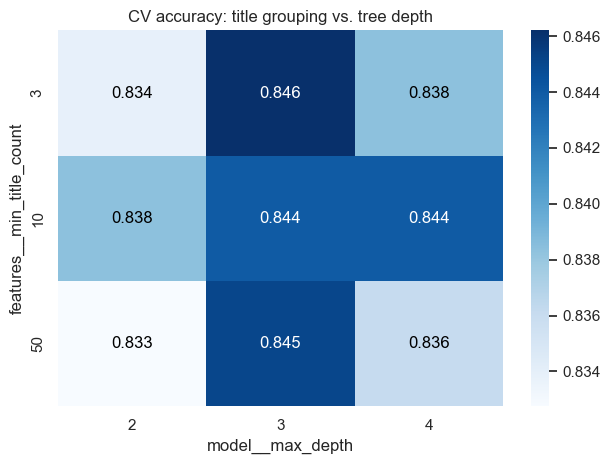

In [10]:
grid_results = pd.DataFrame(search.cv_results_)
table = grid_results.pivot_table(index="param_features__min_title_count",
                                 columns="param_model__max_depth",
                                 values="mean_test_score", aggfunc="max")

ax = sns.heatmap(table, cmap="Blues")
for row in range(table.shape[0]):          # write the number into every cell
    for col in range(table.shape[1]):
        value = table.iloc[row, col]
        ax.text(col + 0.5, row + 0.5, f"{value:.3f}", ha="center", va="center",
                color="white" if value > table.values.mean() else "black")
ax.set(title="CV accuracy: title grouping vs. tree depth",
       xlabel="model__max_depth", ylabel="features__min_title_count")
plt.tight_layout()
plt.savefig("../images/pipeline_grid_search.png", dpi=120)
plt.show()

**Reading the chart:**
- A tree depth of **3** is best in every row. Depth 2 is a little too simple, depth 4 starts to overfit.
- How we group titles hardly matters. Even merging `Master` into "Rare" costs almost nothing, because `Age` and `Sex` already tell the model that the passenger is a young boy.
- All nine combinations are within about 1.3 percentage points of each other, which is less than the spread between folds. The "best" setting is only slightly better than the others, so we should not read too much into it.

### Swapping the model

Because the cleaning is separate from the model, trying a different algorithm is a one‑line change.

In [11]:
model_options = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=4, min_samples_leaf=2, random_state=42),
    "Gradient Boosting": gb_tuned,
}

rows = []
for name, model in model_options.items():
    scores = cross_val_score(make_titanic_pipeline(model), X_raw, y, cv=cv, scoring="accuracy")
    rows.append({"model": name, "CV accuracy": scores.mean(), "CV std": scores.std()})

pd.DataFrame(rows).set_index("model").sort_values("CV accuracy", ascending=False).round(3)

,CV accuracy,CV std
model,,
Gradient Boosting,0.843,0.028
Logistic Regression,0.832,0.015
Random Forest,0.822,0.008


## 7. Using the pipeline

### Predicting for a new passenger

This is where pipelines pay off. We describe a passenger with the **same columns as the raw CSV** and ask for a prediction. No manual cleaning, no dummy columns to align.

In [12]:
final_pipeline = search.best_estimator_   # already refitted on all 891 training passengers

new_passengers = pd.DataFrame([
    {"PassengerId": 9001, "Pclass": 1, "Name": "Smith, Mrs. Anna", "Sex": "female", "Age": 35,
     "SibSp": 1, "Parch": 0, "Ticket": "X1", "Fare": 80.0, "Cabin": "C22", "Embarked": "S"},
    {"PassengerId": 9002, "Pclass": 3, "Name": "Jones, Mr. Tom", "Sex": "male", "Age": np.nan,
     "SibSp": 0, "Parch": 0, "Ticket": "X2", "Fare": 7.9, "Cabin": np.nan, "Embarked": "S"},
    {"PassengerId": 9003, "Pclass": 2, "Name": "Brown, Master. Leo", "Sex": "male", "Age": 6,
     "SibSp": 0, "Parch": 2, "Ticket": "X3", "Fare": 26.0, "Cabin": np.nan, "Embarked": "Q"},
])

new_passengers.assign(
    SurvivalChance=final_pipeline.predict_proba(new_passengers)[:, 1].round(2),
    Prediction=np.where(final_pipeline.predict(new_passengers) == 1, "Survived", "Died"),
)[["Name", "Pclass", "Sex", "Age", "SurvivalChance", "Prediction"]]

,Name,Pclass,Sex,Age,SurvivalChance,Prediction
0,"Smith, Mrs. Anna",1,female,35.0,0.94,Survived
1,"Jones, Mr. Tom",3,male,NaN,0.10,Died
2,"Brown, Master. Leo",2,male,6.0,0.82,Survived


The second passenger has no age and no cabin. The pipeline filled the age from his title ("Mr") by itself.

### Predicting `test.csv`

In notebook 02 this needed a 15‑line `prepare_features` function. Now it is one line.

In [13]:
submission_v3 = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": final_pipeline.predict(test_raw).astype(int),
})
submission_v3.to_csv("../submissions/submission_v3_pipeline.csv", index=False)

v1 = pd.read_csv("../submissions/submission.csv")
v2 = pd.read_csv("../submissions/submission_v2_groups_ensemble.csv")
print(f"Saved {len(submission_v3)} predictions to submissions/submission_v3_pipeline.csv")
print(f"Predicted survival rate: {submission_v3['Survived'].mean():.1%}")
print(f"Same prediction as v1 for {(submission_v3['Survived'] == v1['Survived']).mean():.0%} of passengers, "
      f"as v2 for {(submission_v3['Survived'] == v2['Survived']).mean():.0%}")

Saved 418 predictions to submissions/submission_v3_pipeline.csv
Predicted survival rate: 37.1%
Same prediction as v1 for 95% of passengers, as v2 for 93%


This pipeline does **not** contain the group survival feature from notebook 03, so we expected its Kaggle score to be close to submission v1 (0.775), not v2 (0.792).

| Submission | Model | Kaggle public score |
|---|---|---|
| v1 | Gradient Boosting, original features (manual cleaning) | 0.77511 |
| v2 | Voting ensemble + group features (manual cleaning) | 0.79186 |
| v3 | Pipeline: Gradient Boosting, original features + deck | 0.76315 |

**Result: 0.763, slightly *below* v1.** The difference is 5 passengers out of 418. In cross‑validation this pipeline looked a little better than the v1 model (0.846 vs. 0.837), but on Kaggle it was a little worse. This is a useful lesson:

- Differences of about one percentage point in cross‑validation are **noise** on a dataset this small. They do not reliably carry over to new data.
- The pipeline did not make the model better or worse. It made the process **safer and reusable**. What actually moved the Kaggle score was a better feature (group survival, +1.7 points in v2).

**Why is group survival not in the pipeline?** That feature is built from the `Survived` labels of *other* passengers. To do it without leakage, each fold would have to compute it using only its own training passengers, and treat training and new passengers differently. That is possible, but it needs more advanced tools than a first pipeline. Knowing which features are "safe" and which need extra care is itself an important real‑world skill.

## 8. What we learned

| Concept | In one sentence |
|---|---|
| **`Pipeline`** | Chains cleaning steps and a model into one object with `fit` and `predict`. |
| **`ColumnTransformer`** | Applies different steps to different columns (numbers vs. categories). |
| **`fit` vs. `transform`** | `fit` *learns* from training data; `transform` *applies* what was learned to any data. |
| **Custom transformer** | Our own features as a reusable pipeline step (`TitanicFeatures`). |
| **Data leakage** | When information from validation or test data sneaks into training. Pipelines prevent it by refitting every step inside each fold. |
| **`step__parameter`** | Tune cleaning choices and model settings together with `GridSearchCV`. |
| **`handle_unknown="ignore"`** | Make the pipeline robust to categories it has never seen. |

**Why this matters in a real job:** a model is only useful if someone else can run it on tomorrow's data. A pipeline makes the whole process repeatable, testable and safe from the most common evaluation mistake.

**Natural next steps:** save the fitted pipeline to a file with `joblib` so it can be used without retraining, move `TitanicFeatures` into a Python module (`src/`), and look inside the model with error analysis and SHAP values.